# Hyperparameter selection for the paper (LGCP + baselines)

Two fixed test weeks are used throughout — **2025-05-01..07** (spring) and
**2025-11-01..07** (autumn) — instead of searching over which week to use.
For every method, hyperparameters are chosen to maximize a **relative,
week-averaged score**: each metric is min-max normalized *within each week*
(so 1.0 = the best combo that week, 0.0 = the worst, regardless of the
metric's raw scale) before averaging across the two weeks. This matters
because May and November traffic levels differ, so a plain arithmetic
average of raw metrics would let whichever week has larger numbers
dominate the choice.

**Method**

1. Train LGCP with every combination of temporal-kernel structure and
   learning rate, on both weeks (grid defined in the first cell below).
2. Score every (kernel, lr) combo by its relative, week-averaged
   `(mean_ll_obs, rmse_daily)`; a combo only qualifies if it converged on
   *both* weeks. Pick the top scorer.
3. Re-train the winning LGCP config at full training length on both weeks.
4. Grid-search each baseline (window Poisson GLM, GNN, last-available
   Poisson) the same way — same two weeks, same relative-average scoring —
   and take the best configuration per method.
5. Assemble a final comparison table (per week + week-average) for all 4
   methods.

All metrics come from `evaluate_metrics()` in `src/models/metrics_lgcp.py`.

## All hyperparameter grids

Everything that varies across this notebook's searches, in one place.

In [1]:
# --- shared ---
YEARS = [2024, 2025]
SEED = 0

TEST_WEEKS = [
    {"label": "may", "test_start": "2025-05-01", "test_end": "2025-05-07"},
    {"label": "november", "test_start": "2025-11-01", "test_end": "2025-11-07"},
]

# Metrics used for the relative, week-averaged score (see methodology
# markdown cell below). "max" = higher is better, "min" = lower is better.
METRIC_DIRECTIONS = {
    "mean_ll_obs": "max",
    "rmse_daily": "min",
}

# --- LGCP ---
LGCP_LR_GRID = [0.001, 0.01, 0.05]

# Temporal-kernel combinations: each is a list of physical periods (days)
# for the periodic components summed with a short-scale RBF. Converted to
# the model's standardized time units per-week (see period_to_std below).
LGCP_KERNEL_SPECS = {
    "weekly": [7.0],
    "monthly": [30.44],
    "yearly": [365.25],
    "weekly+monthly": [7.0, 30.44],
    "weekly+yearly": [7.0, 365.25],
}

LGCP_NUM_STEPS_SEARCH = 1500   # reduced budget for the grid search
LGCP_NUM_STEPS_FINAL = 5000    # full length, used only for the winning config
LGCP_M_INDUCING = 300
LGCP_NUM_MC = 32

# --- Window Poisson GLM ---
GLM_ALPHA_GRID = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]     # standard log-spaced L2 grid
GLM_WINDOW_SIZE_GRID = [3, 7, 14]                    # short / weekly / biweekly context

# --- GNN ---
GNN_HIDDEN_DIM_GRID = [16, 32, 64]
GNN_NUM_LAYERS_GRID = [1, 2, 3]
GNN_LR_GRID = [1e-3, 1e-2]

# --- Last-available Poisson ---
LAST_AVAILABLE_MODES = ["frozen_train", "one_step_ahead"]

BASE_LGCP_CONFIG = "config/train_basic_lgcp_multi_kernel.yaml"
BASE_GLM_CONFIG = "config/14_window_poisson_glm.yaml"
BASE_GNN_CONFIG = "config/15_gnn.yaml"
RESULTS_DIR_NAME = "reports/paper/lgcp_two_week_2025_05_11"

n_lgcp_combos = len(TEST_WEEKS) * len(LGCP_KERNEL_SPECS) * len(LGCP_LR_GRID)
n_glm_combos = len(TEST_WEEKS) * len(GLM_ALPHA_GRID) * len(GLM_WINDOW_SIZE_GRID)
n_gnn_combos = len(TEST_WEEKS) * len(GNN_HIDDEN_DIM_GRID) * len(GNN_NUM_LAYERS_GRID) * len(GNN_LR_GRID)
n_la_combos = len(TEST_WEEKS) * len(LAST_AVAILABLE_MODES)
print(f"Test weeks: {[w['label'] for w in TEST_WEEKS]}")
print(f"LGCP runs: {n_lgcp_combos}  |  GLM runs: {n_glm_combos}  |  GNN runs: {n_gnn_combos}  |  last-available runs: {n_la_combos}")

Test weeks: ['may', 'november']
LGCP runs: 30  |  GLM runs: 30  |  GNN runs: 36  |  last-available runs: 4


In [2]:
from __future__ import annotations

import copy
import importlib.util
import itertools
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.metrics_lgcp import evaluate_metrics


def load_script_module(name, relpath):
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


train_lgcp = load_script_module("train_lgcp", "scripts/11_train_lgcp.py")
last_avail = load_script_module("last_avail", "scripts/13_evaluate_last_available_poisson.py")
window_glm = load_script_module("window_glm", "scripts/14_train_window_poisson_glm.py")
gnn_mod = load_script_module("gnn_mod", "scripts/15_train_gnn.py")

RESULTS_DIR = PROJECT_ROOT / RESULTS_DIR_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Modules loaded OK. Results will be saved under: {RESULTS_DIR}")

Modules loaded OK. Results will be saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11


In [3]:
base_cfg = train_lgcp.load_config(str(PROJECT_ROOT / BASE_LGCP_CONFIG))
base_cfg["years"] = YEARS
base_cfg["M_inducing"] = LGCP_M_INDUCING
base_cfg["parquet_path"] = str(PROJECT_ROOT / base_cfg["parquet_path"])

print(f"Loaded base LGCP config: {BASE_LGCP_CONFIG}")
print(f"  covariate_cols: {base_cfg['covariate_cols']}")
print(f"  spatial kernel (fixed across all runs): {base_cfg['model']['spatial_kernels']}")

Loaded base LGCP config: config/train_basic_lgcp_multi_kernel.yaml
  covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7']
  spatial kernel (fixed across all runs): [{'type': 'rbf', 'hyperparameters': {'lengthscale': 0.35, 'variance': 2.0}, 'trainable': {'lengthscale': False, 'variance': True}}]


## Methodology helpers

**`period_to_std`**: the LGCP's temporal kernels operate on a standardized
time coordinate (`t_std`, z-scored `t_norm`, fit on each run's training
data). A physical period (e.g. exactly 7 days) is therefore not a fixed
constant in `t_std` units — it depends on the loaded data's span and on
that specific week's training-data scaler. Computed per-week from the
fitted scaler rather than hardcoded.

**`build_temporal_model_cfg`**: builds `model.temporal_kernels` as one
short-scale RBF (trainable lengthscale) plus one *fixed-period* periodic
component per entry in the kernel spec — so `"weekly+yearly"` sums three
temporal kernel components (RBF, weekly-periodic, yearly-periodic).

**`compute_relative_scores`**: for each metric, min-max normalizes across
the hyperparameter combos *within each week* (1.0 = best that week), then
averages across weeks per combo. A combo is only kept if it converged on
every week. `combined_relative_score` is the mean of all relative metric
columns and is what every grid search in this notebook ranks by.

In [ ]:
def period_to_std(period_days: float, t_scaler, span_days: float) -> float:
    period_t_norm = period_days / span_days
    return period_t_norm / float(t_scaler.scale_[0])


def build_temporal_model_cfg(base_model_cfg: dict, period_days_list: list[float], t_scaler, span_days: float) -> dict:
    model_cfg = copy.deepcopy(base_model_cfg)
    temporal_kernels = [
        {
            "type": "RBF",
            "hyperparameters": {"lengthscale": 0.08, "variance": 0.5},
            "trainable": {"lengthscale": True, "variance": True},
        }
    ]
    for period_days in period_days_list:
        period_std = period_to_std(period_days, t_scaler, span_days)
        temporal_kernels.append({
            "type": "periodic",
            "hyperparameters": {"lengthscale": 0.50, "variance": 0.2, "period": period_std},
            "trainable": {"lengthscale": True, "variance": True, "period": False},
        })
    model_cfg["temporal_kernels"] = temporal_kernels
    return model_cfg


METRIC_KEYS = [
    "mean_ll_obs", "mae_obs", "rmse_obs",
    "mean_ll_daily", "mae_daily", "rmse_daily",
    "daily_delta_corr", "daily_direction_accuracy_moving",
]


def run_lgcp_combo(
    cfg, train_coords, train_covs, train_y, eval_coords, eval_covs, eval_y, eval_dates,
    lr, num_mc, num_steps, model_cfg, seed=SEED,
):
    """Trains one LGCP config and evaluates it. A high lr can occasionally
    make the variational covariance go non-positive-definite mid-training
    (Cholesky failure) -- caught here and reported as a NaN/failed row
    rather than crashing the whole search."""
    run_cfg = dict(cfg)
    run_cfg["model"] = model_cfg
    run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
    run_cfg["lr"] = lr
    run_cfg["num_mc"] = num_mc
    run_cfg["num_steps"] = num_steps
    run_cfg["log_every"] = max(num_steps, 1)
    m_inducing = min(run_cfg["M_inducing"], train_coords.shape[0])

    train_lgcp.set_seeds(seed)
    model = train_lgcp.SparseLGCP(
        train_coords, train_covs, train_y,
        kernel_config=run_cfg["kernel_config"],
        M_inducing=m_inducing,
        device=run_cfg["device"],
        np_seed=seed,
    )
    train_lgcp.configure_log_noise(model, run_cfg)

    t0 = time.time()
    try:
        train_lgcp.train(model, run_cfg)
        rate_mean, _, _ = model.predict_rate(
            eval_coords, eval_covs, num_samples=run_cfg.get("num_pred_samples", 200)
        )
        metrics = evaluate_metrics(eval_y, rate_mean, eval_dates)
        failed = False
    except RuntimeError as e:
        print(f"    !! training failed ({type(e).__name__}: {e}) -- likely numerical "
              f"instability at this lr/kernel combo. Recording as NaN and continuing.")
        metrics = {k: float("nan") for k in METRIC_KEYS}
        failed = True
    elapsed = time.time() - t0

    metrics["failed"] = failed
    return metrics, elapsed


def pareto_front(df: pd.DataFrame, directions: dict) -> pd.DataFrame:
    """
    directions: {col_name: "max" or "min"}. Generalizes to any number of
    columns, each independently oriented -- important because the
    relative_* columns from compute_relative_scores() are ALWAYS "higher is
    better" (1.0 = best that week) regardless of the original metric's own
    direction, so they must not be passed to this function as if the raw
    metric's direction still applied (e.g. relative_rmse_daily is NOT a
    "minimize" column, even though raw rmse_daily is).
    """
    cols = list(directions)
    sign = np.array([1.0 if directions[c] == "max" else -1.0 for c in cols])
    pts = df[cols].to_numpy() * sign  # higher is always better after this
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        dominated = ((pts >= pts[i]).all(axis=1) & (pts > pts[i]).any(axis=1)).any()
        is_pareto[i] = not dominated
    return df.loc[is_pareto].sort_values(cols[0], ascending=(directions[cols[0]] != "max"))


def compute_relative_scores(df: pd.DataFrame, week_col: str, group_cols: list[str], metrics_directions: dict) -> pd.DataFrame:
    group_cols = list(group_cols)
    valid_df = df.dropna(subset=list(metrics_directions)).copy()

    for metric, direction in metrics_directions.items():
        def _normalize(s, direction=direction):
            lo, hi = s.min(), s.max()
            if hi - lo < 1e-12:
                return pd.Series(1.0, index=s.index)
            return (s - lo) / (hi - lo) if direction == "max" else (hi - s) / (hi - lo)
        valid_df[f"relative_{metric}"] = valid_df.groupby(week_col)[metric].transform(_normalize)

    relative_cols = [f"relative_{m}" for m in metrics_directions]
    n_weeks_total = df[week_col].nunique()
    week_counts = valid_df.groupby(group_cols)[week_col].nunique().rename("n_weeks_valid")

    scores = valid_df.groupby(group_cols)[relative_cols].mean()
    scores["combined_relative_score"] = scores[relative_cols].mean(axis=1)
    scores = scores.join(week_counts).reset_index()

    complete = scores[scores["n_weeks_valid"] == n_weeks_total].copy()
    incomplete = scores[scores["n_weeks_valid"] != n_weeks_total]
    if len(incomplete):
        print(f"  Excluded {len(incomplete)} combo(s) that didn't converge on every week:")
        display(incomplete[group_cols + ["n_weeks_valid"]])
    return complete.sort_values("combined_relative_score", ascending=False)


print("Helpers defined.")

## Step 1 — LGCP grid (weeks x kernels x learning rates)

Data is prepared once per week (shared across its (kernel, lr) combos).

In [5]:
lgcp_rows = []
WEEK_DATA = {}  # cached per-week tensors, reused for the confirm run later
combo_i = 0
total_combos = len(TEST_WEEKS) * len(LGCP_KERNEL_SPECS) * len(LGCP_LR_GRID)
t_start_all = time.time()

for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    print("=" * 80)
    print(f"Week '{label}': test = {test_start} .. {test_end}")
    print("=" * 80)

    (
        train_coords, train_covs, train_y,
        test_coords, test_covs, test_y,
        scalers, df,
    ) = train_lgcp.prepare_data(
        base_cfg["parquet_path"],
        train_fraction=base_cfg["train_fraction"],
        random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window",
        covariate_cols=base_cfg["covariate_cols"],
        test_start_date=test_start,
        test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"),
        years=YEARS,
    )
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df.loc[test_mask, "date"].values
    span_days = (df["date"].max() - df["date"].min()).days
    t_scaler = scalers["t_scaler"]

    WEEK_DATA[label] = dict(
        test_start=test_start, test_end=test_end,
        train_coords=train_coords, train_covs=train_covs, train_y=train_y,
        test_coords=test_coords, test_covs=test_covs, test_y=test_y,
        test_dates=test_dates, span_days=span_days, t_scaler=t_scaler,
    )

    print(f"  Train obs: {train_coords.shape[0]:,}   Test obs: {test_coords.shape[0]:,}   span_days={span_days}")

    for kernel_name, period_days_list in LGCP_KERNEL_SPECS.items():
        model_cfg = build_temporal_model_cfg(base_cfg["model"], period_days_list, t_scaler, span_days)
        for lr in LGCP_LR_GRID:
            combo_i += 1
            metrics, elapsed = run_lgcp_combo(
                base_cfg, train_coords, train_covs, train_y,
                test_coords, test_covs, test_y, test_dates,
                lr=lr, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_SEARCH, model_cfg=model_cfg, seed=SEED,
            )
            print(
                f"  [{combo_i}/{total_combos}] kernel={kernel_name:16s} lr={lr:<6}  "
                f"mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)"
            )
            lgcp_rows.append({
                "week": label,
                "test_start": test_start,
                "test_end": test_end,
                "kernel": kernel_name,
                "lr": lr,
                "num_mc": LGCP_NUM_MC,
                "num_steps": LGCP_NUM_STEPS_SEARCH,
                "elapsed_s": elapsed,
                **metrics,
            })

print(f"\nTotal search time: {(time.time() - t_start_all) / 60:.1f} min")

lgcp_results_df = pd.DataFrame(lgcp_rows)
lgcp_results_df.to_csv(RESULTS_DIR / "lgcp_grid_results.csv", index=False)
lgcp_results_df

Week 'may': test = 2025-05-01 .. 2025-05-07
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
  Train obs: 23,814   Test obs: 343   span_days=730

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/1500]  loss=19830.9805  ll=-849.2515  kl=80.9091  (0.1s)


[  1500/1500]  loss=9207.4385  ll=-384.2090  kl=272.3295  (47.7s)
  [1/30] kernel=weekly           lr=0.001   mean_ll_obs=-0.4958  rmse_daily=11.8040  (48.3s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=19830.9805  ll=-849.2515  kl=80.9091  (0.0s)


[  1500/1500]  loss=7823.6577  ll=-324.8311  kl=269.4327  (48.8s)
  [2/30] kernel=weekly           lr=0.01    mean_ll_obs=-0.4202  rmse_daily=10.2833  (48.8s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=19830.9805  ll=-849.2515  kl=80.9091  (0.0s)


    !! training failed (_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 265 is not positive-definite).) -- likely numerical instability at this lr/kernel combo. Recording as NaN and continuing.
  [3/30] kernel=weekly           lr=0.05    mean_ll_obs=nan  rmse_daily=nan  (0.3s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=20225.9004  ll=-864.4706  kl=121.8924  (0.0s)


...

[  1500/1500]  loss=13874.0391  ll=-423.3039  kl=302.6852  (195.9s)
  [28/30] kernel=weekly+yearly    lr=0.001   mean_ll_obs=-0.5320  rmse_daily=5.6082  (196.0s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/1500]  loss=23732.4902  ll=-737.1003  kl=100.6517  (0.2s)


[  1500/1500]  loss=13390.8984  ll=-408.2498  kl=302.1879  (195.6s)
  [29/30] kernel=weekly+yearly    lr=0.01    mean_ll_obs=-0.5345  rmse_daily=2.5807  (195.6s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=23732.4902  ll=-737.1003  kl=100.6517  (0.1s)


    !! training failed (_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 292 is not positive-definite).) -- likely numerical instability at this lr/kernel combo. Recording as NaN and continuing.
  [30/30] kernel=weekly+yearly    lr=0.05    mean_ll_obs=nan  rmse_daily=nan  (0.6s)

Total search time: 53.8 min


,week,test_start,test_end,kernel,lr,num_mc,num_steps,elapsed_s,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving,failed
0,may,2025-05-01,2025-05-07,weekly,0.001,32,1500,48.292973,-0.495798,0.310309,0.806897,-7.520357,9.284296,11.803975,-0.109429,0.75,False
1,may,2025-05-01,2025-05-07,weekly,0.010,32,1500,48.833453,-0.420225,0.259156,0.741134,-5.805376,6.640541,10.283324,0.366882,0.75,False
2,may,2025-05-01,2025-05-07,weekly,0.050,32,1500,0.269712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,may,2025-05-01,2025-05-07,monthly,0.001,32,1500,52.634465,-0.429555,0.273187,0.754085,-6.199554,7.337894,10.560939,0.238462,0.75,False
4,may,2025-05-01,2025-05-07,monthly,0.010,32,1500,66.337020,-0.392384,0.277081,0.709758,-6.164751,7.690218,10.521490,0.321233,0.75,False
5,may,2025-05-01,2025-05-07,monthly,0.050,32,1500,1.022883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
6,may,2025-05-01,2025-05-07,yearly,0.001,32,1500,151.109746,-0.375966,0.251540,0.709988,-6.041583,6.917444,10.477799,0.264643,0.75,False
7,may,2025-05-01,2025-05-07,yearly,0.010,32,1500,162.147701,-0.389400,0.256133,0.719658,-6.045965,6.832463,10.570731,0.319937,0.75,False
8,may,2025-05-01,2025-05-07,yearly,0.050,32,1500,2.002145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
9,may,2025-05-01,2025-05-07,weekly+monthly,0.001,32,1500,195.177577,-0.510847,0.329849,0.815965,-7.351108,8.801496,11.490276,-0.103753,0.75,False


## Step 2 — Relative, week-averaged score and Pareto front

In [6]:
lgcp_valid_df = lgcp_results_df[~lgcp_results_df["failed"]]
n_failed = int(lgcp_results_df["failed"].sum())
if n_failed:
    print(f"{n_failed}/{len(lgcp_results_df)} LGCP runs failed to converge (see NaN rows).\n")
    display(lgcp_results_df.loc[lgcp_results_df["failed"], ["week", "kernel", "lr"]])

lgcp_scores_df = compute_relative_scores(lgcp_results_df, week_col="week", group_cols=["kernel", "lr"], metrics_directions=METRIC_DIRECTIONS)
print("\nLGCP combos ranked by relative, week-averaged score:")
display(lgcp_scores_df)

# Both relative_* columns are already oriented "higher is better" (1.0 = best
# that week) after compute_relative_scores(), so the Pareto front treats both
# as "max" here -- NOT the raw metric's own direction (rmse_daily is "min",
# but relative_rmse_daily is not).
score_col_ll, score_col_rmse = "relative_mean_ll_obs", "relative_rmse_daily"
lgcp_pareto_df = pareto_front(lgcp_scores_df, {score_col_ll: "max", score_col_rmse: "max"})
print(f"\nPareto front over the two (week-averaged, relative) axes: {len(lgcp_pareto_df)}/{len(lgcp_scores_df)} combos")
display(lgcp_pareto_df[["kernel", "lr", score_col_ll, score_col_rmse, "combined_relative_score"]])

best_lgcp_row = lgcp_scores_df.iloc[0]
BEST_LGCP_KERNEL = best_lgcp_row["kernel"]
BEST_LGCP_LR = float(best_lgcp_row["lr"])
print(f"\nSelected LGCP config: kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  "
      f"(combined_relative_score={best_lgcp_row['combined_relative_score']:.4f})")

10/30 LGCP runs failed to converge (see NaN rows).



,week,kernel,lr
2,may,weekly,0.05
5,may,monthly,0.05
8,may,yearly,0.05
11,may,weekly+monthly,0.05
14,may,weekly+yearly,0.05
17,november,weekly,0.05
20,november,monthly,0.05
23,november,yearly,0.05
26,november,weekly+monthly,0.05
29,november,weekly+yearly,0.05



LGCP combos ranked by relative, week-averaged score:


,kernel,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
8,yearly,0.001,1.000000,0.785047,0.892524,2
7,weekly+yearly,0.010,0.536274,1.000000,0.768137,2
3,weekly,0.010,0.730033,0.592178,0.661105,2
5,weekly+monthly,0.010,0.666209,0.385578,0.525894,2
0,monthly,0.001,0.350860,0.584817,0.467838,2
1,monthly,0.010,0.521027,0.397041,0.459034,2
9,yearly,0.010,0.450201,0.385773,0.417987,2
2,weekly,0.001,0.292728,0.362573,0.327651,2
6,weekly+yearly,0.001,0.393495,0.241281,0.317388,2
4,weekly+monthly,0.001,0.285711,0.341447,0.313579,2



Pareto front over the two (week-averaged, relative) axes: 2/10 combos


,kernel,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score
8,yearly,0.001,1.000000,0.785047,0.892524
7,weekly+yearly,0.010,0.536274,1.000000,0.768137



Selected LGCP config: kernel=yearly  lr=0.001  (combined_relative_score=0.8925)


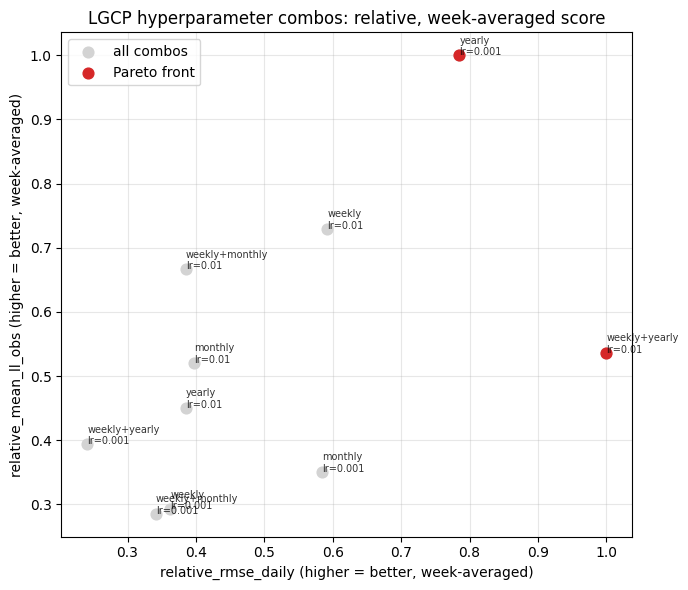

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lgcp_scores_df[score_col_rmse], lgcp_scores_df[score_col_ll], color="lightgray", s=60, label="all combos", zorder=2)
ax.scatter(lgcp_pareto_df[score_col_rmse], lgcp_pareto_df[score_col_ll], color="tab:red", s=60, label="Pareto front", zorder=3)
for _, row in lgcp_scores_df.iterrows():
    ax.annotate(f"{row['kernel']}\nlr={row['lr']}", (row[score_col_rmse], row[score_col_ll]), fontsize=7, alpha=0.8)
ax.set_xlabel(f"{score_col_rmse} (higher = better, week-averaged)")
ax.set_ylabel(f"{score_col_ll} (higher = better, week-averaged)")
ax.set_title("LGCP hyperparameter combos: relative, week-averaged score")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "lgcp_relative_score_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3 — Confirm the winning LGCP configuration at full training length

The search above used a reduced `LGCP_NUM_STEPS_SEARCH` budget. The
winning (kernel, lr) is re-trained here at `LGCP_NUM_STEPS_FINAL` on
*both* weeks (reusing the cached data from Step 1) for the final table.

In [8]:
lgcp_confirm_rows = []
for week in TEST_WEEKS:
    label = week["label"]
    wd = WEEK_DATA[label]
    model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], wd["t_scaler"], wd["span_days"])

    print(f"Confirming on week '{label}' ({wd['test_start']} .. {wd['test_end']}): "
          f"kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_steps={LGCP_NUM_STEPS_FINAL}")
    metrics, elapsed = run_lgcp_combo(
        base_cfg, wd["train_coords"], wd["train_covs"], wd["train_y"],
        wd["test_coords"], wd["test_covs"], wd["test_y"], wd["test_dates"],
        lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
    )
    if metrics["failed"]:
        raise RuntimeError(
            f"Winning LGCP config failed to converge on week '{label}' at full length "
            "(it succeeded during the shorter search). Consider the runner-up in lgcp_scores_df."
        )
    print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
    lgcp_confirm_rows.append({"method": "LGCP", "week": label, **{k: metrics[k] for k in METRIC_KEYS}})

lgcp_confirm_df = pd.DataFrame(lgcp_confirm_rows)
lgcp_confirm_df.to_csv(RESULTS_DIR / "lgcp_confirmed_results.csv", index=False)
lgcp_confirm_df

Confirming on week 'may' (2025-05-01 .. 2025-05-07): kernel=yearly  lr=0.001  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=369842.4062  ll=-15872.4492  kl=714.9666  (0.1s)


[  5000/5000]  loss=8381.9180  ll=-343.6003  kl=391.1970  (560.3s)
  mean_ll_obs=-0.3916  rmse_daily=10.6682  (560.3s)
Confirming on week 'november' (2025-11-01 .. 2025-11-07): kernel=yearly  lr=0.001  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/5000]  loss=665320.9375  ll=-20734.8789  kl=549.3717  (0.1s)


[  5000/5000]  loss=11287.5488  ll=-338.8461  kl=423.9572  (546.9s)
  mean_ll_obs=-0.5491  rmse_daily=6.2179  (546.9s)


,method,week,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
0,LGCP,may,-0.391555,0.250071,0.721558,-6.029116,6.73679,10.668161,0.285739,0.75
1,LGCP,november,-0.549083,0.305267,0.717447,-2.941796,5.01945,6.217857,0.944790,1.00


## Step 4 — Baseline grid searches (same two weeks, same relative-average scoring)

Hyperparameter grids, chosen to be standard/justifiable rather than tuned
(defined in the grids cell at the top):

- **Last-available Poisson**: no continuous hyperparameters — just its two
  prediction modes.
- **Window Poisson GLM**: `poisson_alpha` (L2 regularization) over a
  standard log-spaced grid, x `window_size` (autoregressive context
  length) over short/weekly/biweekly (3/7/14 days).
- **GNN**: `hidden_dim` and `num_layers` over typical small-GCN
  capacities, x `lr` over a standard Adam range.

In [9]:
la_cfg = last_avail.load_config(None)
la_cfg["years"] = YEARS
la_cfg["parquet_path"] = str(PROJECT_ROOT / la_cfg["parquet_path"])

la_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    for mode in LAST_AVAILABLE_MODES:
        (_, _, _, _, _, test_y, _, df_la) = last_avail.prepare_data(
            la_cfg["parquet_path"], train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
            years=YEARS,
        )
        df_la["date"] = pd.to_datetime(df_la["date"])
        train_mask, test_mask = last_avail.make_day_split_masks(
            df=df_la, train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        )
        test_dates = df_la.loc[test_mask, "date"].values
        preds = last_avail.build_last_available_predictions(df=df_la, train_mask=train_mask, test_mask=test_mask, mode=mode)
        metrics = evaluate_metrics(test_y, preds, test_dates)
        print(f"[week={label} mode={mode}] mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}")
        la_rows.append({"week": label, "mode": mode, **metrics})

la_results_df = pd.DataFrame(la_rows)
la_results_df.to_csv(RESULTS_DIR / "last_available_grid_results.csv", index=False)
la_scores_df = compute_relative_scores(la_results_df, week_col="week", group_cols=["mode"], metrics_directions=METRIC_DIRECTIONS)
display(la_scores_df)
best_la_mode = la_scores_df.iloc[0]["mode"]
print(f"Selected last-available mode: {best_la_mode}")

[week=may mode=frozen_train] mean_ll_obs=-1.8278  rmse_daily=21.2872


[week=may mode=one_step_ahead] mean_ll_obs=-2.7974  rmse_daily=15.1186


[week=november mode=frozen_train] mean_ll_obs=-2.7569  rmse_daily=12.7560
[week=november mode=one_step_ahead] mean_ll_obs=-2.2659  rmse_daily=9.0711


,mode,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
1,one_step_ahead,0.5,1.0,0.75,2
0,frozen_train,0.5,0.0,0.25,2


Selected last-available mode: one_step_ahead


In [10]:
glm_cfg = window_glm.load_config(str(PROJECT_ROOT / BASE_GLM_CONFIG))
glm_cfg["years"] = YEARS
glm_cfg["parquet_path"] = str(PROJECT_ROOT / glm_cfg["parquet_path"])

df_glm_raw = window_glm.load_parquet_years(glm_cfg["parquet_path"], YEARS)
df_glm_raw["date"] = pd.to_datetime(df_glm_raw["date"])

glm_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    for window_size in GLM_WINDOW_SIZE_GRID:
        cfg_ws = dict(glm_cfg)
        cfg_ws["window_size"] = window_size
        df_win, feature_cols = window_glm.build_window_dataframe(df_glm_raw, cfg_ws)
        train_mask, test_mask = window_glm.make_split_masks(
            dates=df_win["date"], split_strategy="fixed_test_window",
            train_fraction=cfg_ws["train_fraction"], random_seed=cfg_ws["data_seed"],
            test_start_date=test_start, test_end_date=test_end,
        )
        X = df_win[feature_cols].values.astype(np.float32)
        y = df_win[cfg_ws["target_col"]].values.astype(np.float32)
        dts = df_win["date"].values
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        test_dates = dts[test_mask]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        for alpha in GLM_ALPHA_GRID:
            model = PoissonRegressor(alpha=alpha, max_iter=cfg_ws["max_iter"])
            model.fit(X_train_s, y_train)
            preds = np.clip(model.predict(X_test_s), 0, None)
            metrics = evaluate_metrics(y_test, preds, test_dates)
            glm_rows.append({"week": label, "window_size": window_size, "poisson_alpha": alpha, **metrics})
    print(f"[week={label}] GLM grid done.")

glm_results_df = pd.DataFrame(glm_rows)
glm_results_df.to_csv(RESULTS_DIR / "glm_grid_results.csv", index=False)
glm_scores_df = compute_relative_scores(glm_results_df, week_col="week", group_cols=["window_size", "poisson_alpha"], metrics_directions=METRIC_DIRECTIONS)
display(glm_scores_df.head(10))
best_glm_row = glm_scores_df.iloc[0]
BEST_GLM_WINDOW_SIZE = int(best_glm_row["window_size"])
BEST_GLM_ALPHA = float(best_glm_row["poisson_alpha"])
print(f"Selected GLM config: window_size={BEST_GLM_WINDOW_SIZE}  poisson_alpha={BEST_GLM_ALPHA}")

Generated lag features: ['cell_lag_1', 'cell_lag_7']


Generated lag features: ['cell_lag_1', 'cell_lag_7']


Generated lag features: ['cell_lag_1', 'cell_lag_7']


[week=may] GLM grid done.
Generated lag features: ['cell_lag_1', 'cell_lag_7']


Generated lag features: ['cell_lag_1', 'cell_lag_7']


Generated lag features: ['cell_lag_1', 'cell_lag_7']


[week=november] GLM grid done.


,window_size,poisson_alpha,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
10,14,0.0001,1.000000,0.961241,0.980621,2
11,14,0.0010,0.997339,0.956164,0.976751,2
12,14,0.0100,0.966886,0.908949,0.937917,2
0,3,0.0001,0.796934,0.936581,0.866758,2
1,3,0.0010,0.794821,0.932332,0.863577,2
2,3,0.0100,0.765656,0.889260,0.827458,2
5,7,0.0001,0.729434,0.782639,0.756037,2
6,7,0.0010,0.725826,0.776943,0.751384,2
7,7,0.0100,0.691333,0.729983,0.710658,2
13,14,0.1000,0.763799,0.632859,0.698329,2


Selected GLM config: window_size=14  poisson_alpha=0.0001


In [11]:
gnn_cfg = gnn_mod.load_config(str(PROJECT_ROOT / BASE_GNN_CONFIG))
gnn_cfg["years"] = YEARS
gnn_cfg["parquet_path"] = str(PROJECT_ROOT / gnn_cfg["parquet_path"])
device = torch.device(gnn_cfg.get("device", "cpu"))

df_gnn = gnn_mod.load_parquet_years(gnn_cfg["parquet_path"], YEARS)
df_gnn["date"] = pd.to_datetime(df_gnn["date"])
df_feat, feature_cols = gnn_mod.build_node_features(df_gnn, gnn_cfg)
X, Y, dates, cell_coords = gnn_mod.build_graph_tensors(df_feat, feature_cols, gnn_cfg["target_col"])
n_dates, n_cells, n_features = X.shape

adj = gnn_mod.build_grid_adjacency(
    cell_coords[["longitude", "latitude"]].to_numpy(), connectivity=gnn_cfg.get("adjacency", "queen")
)
adj_norm = gnn_mod.normalize_adjacency(adj)
adj_norm_t = torch.tensor(adj_norm, dtype=torch.float32, device=device)

gnn_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    train_mask, test_mask = gnn_mod.make_day_split_masks(
        df=pd.DataFrame({"date": dates}), train_fraction=gnn_cfg["train_fraction"], random_seed=gnn_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    X_train, Y_train = X[train_mask], Y[train_mask]
    X_test, Y_test = X[test_mask], Y[test_mask]
    dates_test = dates[test_mask]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_features))
    X_train_model = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_model = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

    X_train_t = torch.tensor(X_train_model, dtype=torch.float32, device=device)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test_model, dtype=torch.float32, device=device)

    for hidden_dim, num_layers, lr in itertools.product(GNN_HIDDEN_DIM_GRID, GNN_NUM_LAYERS_GRID, GNN_LR_GRID):
        torch.manual_seed(SEED)
        model = gnn_mod.SpatioTemporalGNN(
            in_dim=n_features, hidden_dim=hidden_dim, num_layers=num_layers, dropout=gnn_cfg["dropout"],
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=gnn_cfg["weight_decay"])

        model.train()
        for epoch in range(1, int(gnn_cfg["num_epochs"]) + 1):
            optimizer.zero_grad()
            rate_train = model(X_train_t, adj_norm_t)
            loss = gnn_mod.poisson_nll(rate_train, Y_train_t)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            rate_test = model(X_test_t, adj_norm_t).cpu().numpy()
        rate_test = np.clip(rate_test, 0, None)

        y_test_flat = Y_test.reshape(-1)
        rate_test_flat = rate_test.reshape(-1)
        test_dates_flat = np.repeat(dates_test, n_cells)
        metrics = evaluate_metrics(y_test_flat, rate_test_flat, test_dates_flat)
        gnn_rows.append({"week": label, "hidden_dim": hidden_dim, "num_layers": num_layers, "lr": lr, **metrics})
    print(f"[week={label}] GNN grid done.")

gnn_results_df = pd.DataFrame(gnn_rows)
gnn_results_df.to_csv(RESULTS_DIR / "gnn_grid_results.csv", index=False)
gnn_scores_df = compute_relative_scores(gnn_results_df, week_col="week", group_cols=["hidden_dim", "num_layers", "lr"], metrics_directions=METRIC_DIRECTIONS)
display(gnn_scores_df.head(10))
best_gnn_row = gnn_scores_df.iloc[0]
BEST_GNN_HIDDEN_DIM = int(best_gnn_row["hidden_dim"])
BEST_GNN_NUM_LAYERS = int(best_gnn_row["num_layers"])
BEST_GNN_LR = float(best_gnn_row["lr"])
print(f"Selected GNN config: hidden_dim={BEST_GNN_HIDDEN_DIM}  num_layers={BEST_GNN_NUM_LAYERS}  lr={BEST_GNN_LR}")

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']


[week=may] GNN grid done.


[week=november] GNN grid done.


,hidden_dim,num_layers,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
9,32,2,0.010,0.712880,0.833247,0.773064,2
3,16,2,0.010,0.563784,0.827269,0.695526,2
15,64,2,0.010,0.867416,0.456982,0.662199,2
13,64,1,0.010,0.510438,0.631181,0.570810,2
11,32,3,0.010,0.512921,0.610142,0.561532,2
17,64,3,0.010,0.671214,0.386755,0.528985,2
1,16,1,0.010,0.453465,0.501642,0.477553,2
4,16,3,0.001,0.105659,0.794011,0.449835,2
14,64,2,0.001,0.297191,0.592706,0.444948,2
7,32,1,0.010,0.398235,0.482364,0.440299,2


Selected GNN config: hidden_dim=32  num_layers=2  lr=0.01


## Final comparison table

In [12]:
baseline_rows = []
for row in la_results_df[la_results_df["mode"] == best_la_mode].to_dict("records"):
    baseline_rows.append({"method": "Last Available Poisson", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})
for row in glm_results_df[
    (glm_results_df["window_size"] == BEST_GLM_WINDOW_SIZE) & (glm_results_df["poisson_alpha"] == BEST_GLM_ALPHA)
].to_dict("records"):
    baseline_rows.append({"method": "Window Poisson GLM", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})
for row in gnn_results_df[
    (gnn_results_df["hidden_dim"] == BEST_GNN_HIDDEN_DIM)
    & (gnn_results_df["num_layers"] == BEST_GNN_NUM_LAYERS)
    & (gnn_results_df["lr"] == BEST_GNN_LR)
].to_dict("records"):
    baseline_rows.append({"method": "GNN", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})

final_by_week_df = pd.concat([lgcp_confirm_df, pd.DataFrame(baseline_rows)], ignore_index=True)
final_by_week_df.to_csv(RESULTS_DIR / "final_comparison_by_week.csv", index=False)

hyperparameters = {
    "LGCP": f"kernel={BEST_LGCP_KERNEL}, lr={BEST_LGCP_LR}, num_mc={LGCP_NUM_MC}, num_steps={LGCP_NUM_STEPS_FINAL}",
    "Window Poisson GLM": f"window_size={BEST_GLM_WINDOW_SIZE}, poisson_alpha={BEST_GLM_ALPHA}",
    "GNN": f"hidden_dim={BEST_GNN_HIDDEN_DIM}, num_layers={BEST_GNN_NUM_LAYERS}, lr={BEST_GNN_LR}",
    "Last Available Poisson": f"mode={best_la_mode}",
}

final_avg_df = final_by_week_df.groupby("method")[METRIC_KEYS].mean()
final_avg_df.insert(0, "hyperparameters", final_avg_df.index.map(hyperparameters))
final_avg_df = final_avg_df.loc[["LGCP", "Window Poisson GLM", "GNN", "Last Available Poisson"]]
final_avg_df.to_csv(RESULTS_DIR / "final_comparison_avg.csv")

print("Per-week detail:")
display(final_by_week_df.set_index(["method", "week"]))

print(f"\nWeek-averaged final comparison (weeks: {[w['label'] for w in TEST_WEEKS]}):")
print(f"All intermediate results + this table saved under: {RESULTS_DIR}\n")
final_avg_df

Per-week detail:


mean_ll_obs   mae_obs  rmse_obs  \
method                 week                                        
LGCP                   may         -0.391555  0.250071  0.721558   
                       november    -0.549083  0.305267  0.717447   
Last Available Poisson may         -2.797441  0.285714  0.938332   
                       november    -2.265950  0.285714  0.732423   
Window Poisson GLM     may         -0.484127  0.291165  0.783549   
                       november    -0.570337  0.383890  0.752402   
GNN                    may         -0.421341  0.265900  0.756374   
                       november    -0.541930  0.327014  0.717327   

                                 mean_ll_daily  mae_daily  rmse_daily  \
method                 week                                             
LGCP                   may           -6.029116   6.736790   10.668161   
                       november      -2.941796   5.019450    6.217857   
Last Available Poisson may          -70.301578  12.285714   15.118579   
                       november     -64.801121   6.857143    9.071147   
Window Poisson GLM     may           -6.181033   7.181133   10.762136   
                       november      -2.360742   3.347474    4.559527   
GNN                    may           -5.384786   6.841281    9.461209   
                       november      -1.986969   1.063812    1.435756   

                                 daily_delta_corr  \
method                 week                         
LGCP                   may               0.285739   
                       november          0.944790   
Last Available Poisson may              -0.029702   
                       november          0.146487   
Window Poisson GLM     may               0.392578   
                       november          0.931263   
GNN                    may               0.277140   
                       november          0.976629   

                                 daily_direction_accuracy_moving  
method                 week                                       
LGCP                   may                                  0.75  
                       november                             1.00  
Last Available Poisson may                                  0.25  
                       november                             0.25  
Window Poisson GLM     may                                  0.75  
                       november                             1.00  
GNN                    may                                  1.00  
                       november                             1.00


Week-averaged final comparison (weeks: ['may', 'november']):
All intermediate results + this table saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11



,hyperparameters,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,,
LGCP,"kernel=yearly, lr=0.001, num_mc=32, num_steps=...",-0.470319,0.277669,0.719502,-4.485456,5.878120,8.443009,0.615265,0.875
Window Poisson GLM,"window_size=14, poisson_alpha=0.0001",-0.527232,0.337527,0.767976,-4.270887,5.264304,7.660832,0.661921,0.875
GNN,"hidden_dim=32, num_layers=2, lr=0.01",-0.481636,0.296457,0.736850,-3.685878,3.952546,5.448483,0.626885,1.000
Last Available Poisson,mode=one_step_ahead,-2.531695,0.285714,0.835377,-67.551349,9.571429,12.094863,0.058393,0.250


**Notes for the paper writeup**

- All 4 methods are evaluated on the identical two test weeks and trained
  on the identical `years=[2024, 2025]` data available before each week.
- Every method's hyperparameters were chosen the same way: grid search
  both weeks, score by the relative (min-max normalized per week) average
  of `(mean_ll_obs, rmse_daily)`, keep only combos that converged on both
  weeks, take the top scorer.
- `final_comparison_by_week.csv` has the per-week breakdown;
  `final_comparison_avg.csv` is the headline week-averaged table above.
- `lgcp_relative_score_pareto.png` shows the LGCP kernel/lr trade-off
  surface for the appendix/supplementary material.

## Step 5 — Closing the daily-metric gap with GNN

LGCP wins on `mean_ll_obs` (the selection metric) but loses to GNN on every
daily-aggregate metric. The GNN and LGCP currently use the *same*
`covariate_cols` (`cell_roll_mean_7` / `daily_total_lag_*` are disabled in
both `config/15_gnn.yaml` and `config/train_basic_lgcp_multi_kernel.yaml`),
so that's not the cause -- it's architectural: the LGCP's rate is
`exp(alpha + beta @ covariates + f_spatial + f_temporal)`, i.e. a single
*global linear* covariate effect shared across every cell/day, plus smooth
additive GP corrections. The GNN's graph convolutions let it learn
cell- and day-specific nonlinear combinations of the same features,
including same-day signal from neighboring cells -- exactly what
daily-aggregate metrics are sensitive to (correlated same-day misses
across many cells compound when summed, even if each cell's own
log-likelihood looks fine in isolation).

Cheapest thing to test: `daily_total_lag_1`, `daily_total_lag_7`,
`daily_total_roll_mean_7`, and `cell_roll_mean_7` are already computed by
the LGCP's `lag_features` block but never added to `covariate_cols`. They
give the model a direct linear proxy for "today's expected regional
total" from recent history, which should help daily calibration even
within the linear-covariate structure. Tested here by re-training the
already-selected winning (kernel, lr) with these four features added --
overridden locally in this notebook, not written back to the shared
config, since this is a diagnostic, not (yet) a decision to change the
official run.

In [6]:
extra_lag_cols = ["cell_roll_mean_7", "daily_total_lag_1", "daily_total_lag_7", "daily_total_roll_mean_7"]
enriched_covariate_cols = list(base_cfg["covariate_cols"]) + [
    c for c in extra_lag_cols if c not in base_cfg["covariate_cols"]
]
print(f"Original covariate_cols: {base_cfg['covariate_cols']}")
print(f"Enriched covariate_cols: {enriched_covariate_cols}")

lgcp_enriched_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    (
        train_coords, train_covs, train_y,
        test_coords, test_covs, test_y,
        scalers, df,
    ) = train_lgcp.prepare_data(
        base_cfg["parquet_path"],
        train_fraction=base_cfg["train_fraction"],
        random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window",
        covariate_cols=enriched_covariate_cols,
        test_start_date=test_start,
        test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"),
        years=YEARS,
    )
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df.loc[test_mask, "date"].values
    span_days = (df["date"].max() - df["date"].min()).days
    t_scaler = scalers["t_scaler"]
    model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)

    print(f"\nTraining enriched-covariate LGCP on week '{label}' ({test_start} .. {test_end}): "
          f"kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_steps={LGCP_NUM_STEPS_FINAL}")
    metrics, elapsed = run_lgcp_combo(
        base_cfg, train_coords, train_covs, train_y,
        test_coords, test_covs, test_y, test_dates,
        lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
    )
    print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
    lgcp_enriched_rows.append({"method": "LGCP (+ daily-total lag features)", "week": label, **{k: metrics[k] for k in METRIC_KEYS}})

lgcp_enriched_df = pd.DataFrame(lgcp_enriched_rows)
lgcp_enriched_df.to_csv(RESULTS_DIR / "lgcp_enriched_covariates_results.csv", index=False)

comparison_df = pd.concat(
    [
        lgcp_confirm_df,
        lgcp_enriched_df,
        final_by_week_df[final_by_week_df["method"] == "GNN"],
    ],
    ignore_index=True,
)
print("\nLGCP (original) vs LGCP (+ daily-total lag features) vs GNN, per week:")
display(comparison_df.set_index(["method", "week"])[["mean_ll_obs", "mean_ll_daily", "mae_daily", "rmse_daily"]])

comparison_avg_df = comparison_df.groupby("method")[METRIC_KEYS].mean()
comparison_avg_df = comparison_avg_df.loc[["LGCP", "LGCP (+ daily-total lag features)", "GNN"]]
comparison_avg_df.to_csv(RESULTS_DIR / "lgcp_daily_metric_experiment.csv")
print("\nWeek-averaged:")
comparison_avg_df

Original covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7']
Enriched covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training enriched-covariate LGCP on week 'may' (2025-05-01 .. 2025-05-07): kernel=yearly  lr=0.001  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/5000]  loss=369842.4062  ll=-15872.4492  kl=714.9666  (0.0s)


[  5000/5000]  loss=8212.1562  ll=-336.0854  kl=396.2026  (157.4s)
  mean_ll_obs=-0.3730  rmse_daily=9.5485  (157.9s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training enriched-covariate LGCP on week 'november' (2025-11-01 .. 2025-11-07): kernel=yearly  lr=0.001  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=665320.9375  ll=-20734.8789  kl=549.3717  (0.0s)


[  5000/5000]  loss=11275.5088  ll=-338.3488  kl=427.8611  (186.8s)
  mean_ll_obs=-0.5392  rmse_daily=5.7405  (186.8s)

LGCP (original) vs LGCP (+ daily-total lag features) vs GNN, per week:


mean_ll_obs  mean_ll_daily  \
method                            week                                   
LGCP                              may         -0.391555      -6.029116   
                                  november    -0.549083      -2.941796   
LGCP (+ daily-total lag features) may         -0.373008      -5.369359   
                                  november    -0.539212      -2.784568   
GNN                               may         -0.421341      -5.384786   
                                  november    -0.541930      -1.986969   

                                            mae_daily  rmse_daily  
method                            week                             
LGCP                              may        6.736790   10.668161  
                                  november   5.019450    6.217857  
LGCP (+ daily-total lag features) may        6.307131    9.548453  
                                  november   4.716004    5.740474  
GNN                               may        6.841281    9.461209  
                                  november   1.063812    1.435756


Week-averaged:


,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,
LGCP,-0.470319,0.277669,0.719502,-4.485456,5.878120,8.443009,0.615264,0.875
LGCP (+ daily-total lag features),-0.456110,0.276885,0.700522,-4.076963,5.511568,7.644463,0.630014,0.875
GNN,-0.481635,0.296457,0.736851,-3.685878,3.952547,5.448482,0.626884,1.000


## Step 6 — Does a more flexible spatial kernel help?

Every run so far (Steps 1-5) used the same spatial kernel: a single RBF
with a **fixed, never-tuned lengthscale (0.35)** -- only the temporal
kernel and learning rate were ever varied. Since the daily-aggregate gap
with GNN is about correlated errors across many cells at once, spatial
rigidity is a plausible contributor alongside the temporal structure.

Three spatial-kernel variants are compared here, holding the winning
temporal kernel (`BEST_LGCP_KERNEL`), `BEST_LGCP_LR`, and the (now
enriched, per Step 5) `covariate_cols` fixed:

- `rbf_fixed_lengthscale` -- the current default (baseline for this step).
- `rbf_trainable_lengthscale` -- same RBF, but the lengthscale is let the
  optimizer choose it instead of pinning it at 0.35.
- `rational_quadratic` -- a scale-mixture of RBFs (already scaffolded as a
  commented-out option in the config), which can represent both local
  hotspots and broader regional smoothness at once instead of one fixed
  scale.

In [6]:
SPATIAL_KERNEL_SPECS = {
    "rbf_fixed_lengthscale": {
        "type": "RBF",
        "hyperparameters": {"lengthscale": 0.35, "variance": 2.0},
        "trainable": {"lengthscale": False, "variance": True},
    },
    "rbf_trainable_lengthscale": {
        "type": "RBF",
        "hyperparameters": {"lengthscale": 0.35, "variance": 2.0},
        "trainable": {"lengthscale": True, "variance": True},
    },
    "rational_quadratic": {
        "type": "RationalQuadratic",
        "hyperparameters": {"lengthscale": 1.2, "variance": 0.35, "alpha": 0.8},
        "trainable": {"lengthscale": True, "variance": True, "alpha": False},
    },
}

print(f"covariate_cols used for this step: {base_cfg['covariate_cols']}")

spatial_rows = []
for spatial_name, spatial_spec in SPATIAL_KERNEL_SPECS.items():
    for week in TEST_WEEKS:
        label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

        (
            train_coords, train_covs, train_y,
            test_coords, test_covs, test_y,
            scalers, df,
        ) = train_lgcp.prepare_data(
            base_cfg["parquet_path"],
            train_fraction=base_cfg["train_fraction"],
            random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window",
            covariate_cols=base_cfg["covariate_cols"],
            test_start_date=test_start,
            test_end_date=test_end,
            lag_features=base_cfg.get("lag_features"),
            years=YEARS,
        )
        _, test_mask = train_lgcp.make_day_split_masks(
            df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        )
        test_dates = df.loc[test_mask, "date"].values
        span_days = (df["date"].max() - df["date"].min()).days
        t_scaler = scalers["t_scaler"]

        model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)
        model_cfg["spatial_kernels"] = [copy.deepcopy(spatial_spec)]

        print(f"\nTraining spatial={spatial_name} on week '{label}' ({test_start} .. {test_end}) ...")
        metrics, elapsed = run_lgcp_combo(
            base_cfg, train_coords, train_covs, train_y,
            test_coords, test_covs, test_y, test_dates,
            lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
        )
        print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
        spatial_rows.append({"spatial_kernel": spatial_name, "week": label, **metrics})

spatial_results_df = pd.DataFrame(spatial_rows)
spatial_results_df.to_csv(RESULTS_DIR / "lgcp_spatial_kernel_results.csv", index=False)

spatial_scores_df = compute_relative_scores(
    spatial_results_df, week_col="week", group_cols=["spatial_kernel"], metrics_directions=METRIC_DIRECTIONS
)
print("\nSpatial kernel variants ranked by relative, week-averaged score:")
display(spatial_scores_df)

spatial_avg_df = spatial_results_df.groupby("spatial_kernel")[METRIC_KEYS].mean()
spatial_avg_df.to_csv(RESULTS_DIR / "lgcp_spatial_kernel_avg.csv")
print("\nWeek-averaged metrics per spatial kernel:")
spatial_avg_df

covariate_cols used for this step: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_fixed_lengthscale on week 'may' (2025-05-01 .. 2025-05-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/5000]  loss=369842.4062  ll=-15872.4492  kl=714.9666  (0.0s)


[  5000/5000]  loss=8212.1562  ll=-336.0854  kl=396.2026  (175.1s)
  mean_ll_obs=-0.3730  rmse_daily=9.5485  (175.8s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_fixed_lengthscale on week 'november' (2025-11-01 .. 2025-11-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=665320.9375  ll=-20734.8789  kl=549.3717  (0.0s)


[  5000/5000]  loss=11275.5088  ll=-338.3488  kl=427.8611  (186.4s)
  mean_ll_obs=-0.5392  rmse_daily=5.7405  (186.5s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_trainable_lengthscale on week 'may' (2025-05-01 .. 2025-05-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=369842.4062  ll=-15872.4492  kl=714.9666  (0.0s)


[  5000/5000]  loss=8150.0166  ll=-332.8328  kl=409.7047  (189.4s)
  mean_ll_obs=-0.4062  rmse_daily=11.2033  (189.5s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_trainable_lengthscale on week 'november' (2025-11-01 .. 2025-11-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=665320.9375  ll=-20734.8789  kl=549.3717  (0.0s)


...

[  5000/5000]  loss=8022.2422  ll=-326.0442  kl=439.8041  (205.7s)
  mean_ll_obs=-0.4577  rmse_daily=17.6642  (205.7s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rational_quadratic on week 'november' (2025-11-01 .. 2025-11-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=33634.8867  ll=-844.9666  kl=6544.7954  (0.0s)


[  5000/5000]  loss=11066.6543  ll=-329.9589  kl=487.9936  (191.5s)
  mean_ll_obs=-0.4769  rmse_daily=5.6321  (191.5s)

Spatial kernel variants ranked by relative, week-averaged score:


,spatial_kernel,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
2,rbf_trainable_lengthscale,0.390581,0.898049,0.644315,2
1,rbf_fixed_lengthscale,0.500000,0.500000,0.500000,2
0,rational_quadratic,0.500000,0.052805,0.276402,2



Week-averaged metrics per spatial kernel:


,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
spatial_kernel,,,,,,,,
rational_quadratic,-0.467268,0.341453,0.794365,-6.043242,8.732134,11.648162,0.687120,0.875
rbf_fixed_lengthscale,-0.456110,0.276885,0.700522,-4.076963,5.511568,7.644463,0.630014,0.875
rbf_trainable_lengthscale,-0.467309,0.309820,0.743488,-4.362487,5.812821,7.958762,0.621555,0.875
